# Step 5 - Fine-tune EoMT-COCO on Cityscapes (configurable strategy)

Fine-tuning pipeline. Starts from `models/eomt_coco.bin` (panoptic, 133 classes) and re-targets it to Cityscapes 19-class semantic segmentation.

A single `STRATEGY` variable at the top selects what gets trained:

* **`head_only`** - freeze the DINOv2 backbone, train only the prediction head (`q`, `class_head`, `mask_head`, `upscale`) plus **LoRA** adapters on the encoder attention (`qkv`, `proj`). Fast, small trainable budget. Good first pass.
* **`full`** - train every parameter, with a **discriminative LR** (head ~1e-4, backbone ~1e-5). Slower, much larger trainable budget, expected to give the best mIoU.
* **`phased`** - progressive unfreezing in **3 phases** over the run: **phase 0** = head only, **phase 1** = head + last `UNFREEZE_LAST_N` encoder backbone blocks, **phase 2** = full network. Discriminative LR (head 10x backbone). The phase is recomputed from the current optimizer step after every step, so the run rebalances itself automatically — no need to start a new training session per phase. This matches the recommendation *"first fine-tune only the prediction head, then gradually unfreeze later layers"*.

Output is split across two folders, one strategy-specific subfolder each:

* **Intermediate checkpoints** -> `checkpoints/{STRATEGY}/`
  * `ckpt_latest.pt` - full training state for resumption (model + optimizer + scheduler + scaler + step + best_miou).
  * `ckpt_best.pt`   - same shape, frozen at the highest val mIoU seen during training.
* **Final model weights** -> `models/coco_finetune/{STRATEGY}/`
  * `eomt_finetuned_{STRATEGY}.bin` - **model-only weights** (no optimizer state), ready to be loaded by Steps 6-8 in the same way as the provided `eomt_*.bin`.

After the full final evaluation, a per-strategy block is appended to `step5_results.txt` in the repo root (with both **strict** and **common** mIoU, same convention as Step 4) so you can re-run the notebook with a different `STRATEGY` and accumulate results.

**Multi-machine resilience.** Every `CKPT_EVERY_STEPS` we save a full checkpoint to Drive. On startup we resume from the strategy's `ckpt_latest.pt` automatically. For `phased`, the correct phase is re-derived from the resumed `global_step` so a session continuing across phase boundaries does the right thing.

Helpers are imported from [utils/eval_semantic.py](utils/eval_semantic.py) and the vendored [eomt/](eomt/) subtree.

## 1. Mount Drive and pull latest code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation
!git pull origin master

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1Pz7ReDC4oIzyB7KLXs9SnUMvmnDqYbyB/Anomaly-Segmentation
From https://github.com/Lucaaa31/Anomaly-Segmentation
 * branch            master     -> FETCH_HEAD
Already up to date.


## 2. Install dependencies

In [ ]:
!pip install -q lightning timm transformers pyyaml torchmetrics fvcore scipy pycocotools

## 3. Imports and paths

Both the project root (for `utils.eval_semantic`) and `eomt/` (for the YAML class_path strings) must be on `sys.path`.

In [ ]:
import math, time, sys
from pathlib import Path

import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

REPO_ROOT = Path('/content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation')
EOMT_DIR  = REPO_ROOT / 'eomt'
DATA_PATH = REPO_ROOT / 'dataset' / 'Validation_Dataset' / 'Cityscapes'
# CKPT_DIR is built per-strategy in the next cell (depends on STRATEGY).

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(EOMT_DIR))

# Helpers from the project subpackage. utils/ is split by concern:
#   utils.build         -> build_model_and_data
#   utils.eval_semantic -> evaluate_semantic, print_iou_table, CS_CLASS_NAMES (mIoU only)
from utils.build import build_model_and_data
from utils.eval_semantic import evaluate_semantic, print_iou_table, CS_CLASS_NAMES

assert torch.cuda.is_available(), 'Enable GPU runtime: Runtime - Change runtime type - T4 GPU'
device = torch.device('cuda')
print('device:', device, '| torch:', torch.__version__, '| GPU:', torch.cuda.get_device_name(0))

device: cuda | torch: 2.10.0+cu128 | GPU: Tesla T4


## 4. Configuration (strategy switcher + hyperparameters)

`STRATEGY` selects which fine-tuning recipe to run. Everything that differs between recipes (LR, total optimizer steps, freeze policy, LoRA on/off) lives in `STRATEGY_CONFIGS`. Checkpoints land in a strategy-specific folder so different runs don't overwrite each other.

The loop saves a checkpoint every `CKPT_EVERY_STEPS` and stops cleanly before the time budget elapses, so the next teammate starting the notebook resumes from the latest checkpoint **of the same strategy**.

In [ ]:
# --- Strategy switcher ------------------------------------------------------
STRATEGY = "head_only"   # "head_only" / "phased" / "full"
assert STRATEGY in ("head_only", "full", "phased"), f"unknown STRATEGY: {STRATEGY}"

# Per-strategy hyperparameters.
#   head_only -> backbone frozen, head + LoRA trained, smaller budget.
#   full      -> all params trained with discriminative LR (head 10x backbone),
#                LoRA disabled (would be redundant when the backbone is unfrozen),
#                larger budget because the optimization landscape is wider.
#   phased    -> progressive unfreezing: head only -> + last N backbone blocks
#                -> full. Discriminative LR (head 10x backbone). LoRA off
#                (the backbone gets unfrozen anyway). PHASE_FRACTIONS sums to 1.
STRATEGY_CONFIGS = {
    "head_only": {
        "use_lora":     True,
        "lr_head":      1e-4,
        "lr_backbone":  0.0,    # backbone frozen
        "lr_lora":      1e-4,
        "total_steps":  12000,
        "warmup_steps": 500,
    },
    "full": {
        "use_lora":     False,
        "lr_head":      1e-4,
        "lr_backbone":  1e-5,   # 10x smaller than the head
        "lr_lora":      0.0,
        "total_steps":  16000,
        "warmup_steps": 1000,
    },
    "phased": {
        "use_lora":         False,
        "lr_head":          1e-4,
        "lr_backbone":      1e-5,             # 10x smaller than the head
        "lr_lora":          0.0,
        "total_steps":      16000,
        "warmup_steps":     750,
        "phase_fractions":  (0.30, 0.30, 0.40),  # head -> +last_n -> full
        "unfreeze_last_n":  4,                # last 4 encoder blocks unfrozen in phase 1
    },
}
cfg = STRATEGY_CONFIGS[STRATEGY]
USE_LORA        = cfg["use_lora"]
LR_HEAD         = cfg["lr_head"]
LR_BACKBONE     = cfg["lr_backbone"]
LR_LORA         = cfg["lr_lora"]
TOTAL_STEPS     = cfg["total_steps"]
WARMUP_STEPS    = cfg["warmup_steps"]
PHASE_FRACTIONS = cfg.get("phase_fractions")  # phased only
UNFREEZE_LAST_N = cfg.get("unfreeze_last_n")  # phased only
print(f'[config] STRATEGY={STRATEGY}  total_steps={TOTAL_STEPS}  '
      f'lr_head={LR_HEAD}  lr_backbone={LR_BACKBONE}  use_lora={USE_LORA}')
if STRATEGY == "phased":
    print(f'[config] phase_fractions={PHASE_FRACTIONS}  unfreeze_last_n={UNFREEZE_LAST_N}')

# --- Per-strategy output folders --------------------------------------------
# Intermediate checkpoints (latest + best, full training state) live under
# `checkpoints/`; the final model-only .bin lives under `models/coco_finetune/`.
# Both directories use a strategy-specific subfolder so different runs do not
# overwrite each other.
CKPT_DIR  = REPO_ROOT / 'checkpoints' / STRATEGY
FINAL_DIR = REPO_ROOT / 'models' / 'coco_finetune' / STRATEGY
CKPT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)
print(f'[config] CKPT_DIR  = {CKPT_DIR}')
print(f'[config] FINAL_DIR = {FINAL_DIR}')

# --- Source weights / config (shared across strategies) ---------------------
COCO_CKPT = REPO_ROOT / 'models' / 'eomt_coco.bin'
CS_CONFIG = EOMT_DIR / 'configs' / 'dinov2' / 'cityscapes' / 'semantic' / 'eomt_base_640.yaml'

# --- Common training hyperparameters ----------------------------------------
IMG_SIZE         = (640, 640)   # smaller than upstream (1024,1024) to fit Colab T4 memory
BATCH_SIZE       = 2            # per-step batch on T4
GRAD_ACCUM       = 8            # effective batch = BATCH_SIZE * GRAD_ACCUM = 16 (matches upstream)
NUM_WORKERS      = 2
WEIGHT_DECAY     = 0.1          # bumped from 0.05 to add stronger regularization
LOG_EVERY_STEPS  = 25
CKPT_EVERY_STEPS = 200
VAL_EVERY_STEPS  = 250          # frequent val so early stopping has fine-grained signal
VAL_MAX_IMAGES   = 100          # cap intermediate val to keep iterations short (-1 = full 500)

# Early stopping on val mIoU. PATIENCE = number of consecutive validations
# without a strict improvement of at least MIN_DELTA before the run is killed.
# With VAL_EVERY_STEPS=250 and PATIENCE=4, training stops after ~1000 optimizer
# steps of plateau — useful for `head_only`, where the trainable budget is tiny
# and the model usually plateaus well before TOTAL_STEPS.
EARLY_STOP_PATIENCE  = 4
EARLY_STOP_MIN_DELTA = 1e-4

# LoRA hyperparameters (only used when USE_LORA=True)
LORA_R     = 8
LORA_ALPHA = 16

# Colab time budget per session (leaves headroom before colab kills the runtime)
TIME_BUDGET_SEC   = int(4.25 * 3600)
SAFETY_MARGIN_SEC = 5 * 60

def fmt(sec):
    h, rem = divmod(sec, 3600); m, s = divmod(rem, 60)
    return f"{h}h {m}m {s}s"

print(f"Maximum time of run: {fmt(TIME_BUDGET_SEC)}")
print(f"Safety margin:       {fmt(SAFETY_MARGIN_SEC)}")
print(f"Effective budget:    {fmt(TIME_BUDGET_SEC - SAFETY_MARGIN_SEC)}")

torch.manual_seed(0)

[config] STRATEGY=head_only  total_steps=12000  lr_head=0.0001  lr_backbone=0.0  use_lora=True
[config] CKPT_DIR  = /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/checkpoints/head_only
[config] FINAL_DIR = /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/models/coco_finetune/head_only
Maximum time of run: 4h 15m 0s
Safety margin:       0h 5m 0s
Effective budget:    4h 10m 0s


## 5. Build the model from the COCO checkpoint

We use the **Cityscapes** YAML config - so the lightning module is shaped for 19 classes - but load weights from `eomt_coco.bin` with `skip_class_head=True`. Encoder, mask head, queries and upscale all come from COCO; the class head is randomly initialized for the new 19-class space.

We override `img_size` so the model is built for 640x640 training crops.

In [ ]:
data_overrides = {
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
}
model, data = build_model_and_data(
    CS_CONFIG, COCO_CKPT, DATA_PATH, device,
    setup_data=True, skip_class_head=True, data_overrides=data_overrides,
)
data.setup()
print(f'num_classes={model.num_classes}  img_size={model.img_size}')
print(f'class_head shape: {tuple(model.network.class_head.weight.shape)}  '
      f'(expected ({model.num_classes + 1}, embed_dim))')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


  [info] skip_class_head: dropped 2 class-head key(s)
  [info] skip_class_head: dropped 2 shape-mismatched key(s):
    network.q.weight: ckpt (200, 768) vs model (100, 768)
    criterion.empty_weight: ckpt (134,) vs model (20,)
  [warn] missing keys: 4
num_classes=19  img_size=(640, 640)
class_head shape: (20, 768)  (expected (20, embed_dim))


## 6. Freeze policy (driven by `STRATEGY`)

* `head_only` - freeze everything, then unfreeze the prediction head: `q`, `class_head`, `mask_head`, `upscale`. The encoder backbone is left frozen and any extra capacity comes from the LoRA adapters added in the next cell.
* `full` - leave all parameters trainable (every `requires_grad = True`).
* `phased` - three-phase progressive unfreezing. **Phase 0** (first `PHASE_FRACTIONS[0]` of total steps): head only. **Phase 1** (next `PHASE_FRACTIONS[1]`): head + last `UNFREEZE_LAST_N` encoder backbone blocks. **Phase 2** (remainder): full network. The phase is recomputed from `global_step` after each optimizer step; the optimizer is built once over **all** parameters (see next cells), so flipping `requires_grad` is enough — `AdamW` skips parameters whose gradient is `None` and lazily initializes momentum state when they are first updated.

Defines the helpers `apply_phase` and `phase_for_step` used by the training loop, plus a small `count_params` for trainable-budget logging.

In [ ]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# --- phased helpers (no-ops when STRATEGY != "phased") ----------------------
def apply_phase(model, phase: int, last_n: int):
    """Set `requires_grad` on the network based on the current training phase.

    phase=0 -> head only (q, class_head, mask_head, upscale)
    phase=1 -> head + last `last_n` encoder backbone blocks
    phase=2 -> full network
    """
    for p in model.parameters():
        p.requires_grad = (phase == 2)
    if phase < 2:
        for module_name in ('q', 'class_head', 'mask_head', 'upscale'):
            for p in getattr(model.network, module_name).parameters():
                p.requires_grad = True
    if phase == 1:
        blocks = list(model.network.encoder.backbone.blocks)
        for blk in blocks[-last_n:]:
            for p in blk.parameters():
                p.requires_grad = True


def phase_for_step(step: int) -> int:
    """Map a global optimizer step to a phase index using PHASE_FRACTIONS."""
    f0, f1, _ = PHASE_FRACTIONS
    boundary_0_1 = int(round(TOTAL_STEPS * f0))
    boundary_1_2 = int(round(TOTAL_STEPS * (f0 + f1)))
    if step < boundary_0_1:
        return 0
    if step < boundary_1_2:
        return 1
    return 2

# --- Apply the strategy's initial freeze policy -----------------------------
if STRATEGY == "head_only":
    for p in model.parameters():
        p.requires_grad = False
    for module_name in ['q', 'class_head', 'mask_head', 'upscale']:
        for p in getattr(model.network, module_name).parameters():
            p.requires_grad = True
elif STRATEGY == "full":
    for p in model.parameters():
        p.requires_grad = True
elif STRATEGY == "phased":
    apply_phase(model, phase=0, last_n=UNFREEZE_LAST_N)
    b01 = int(round(TOTAL_STEPS * PHASE_FRACTIONS[0]))
    b12 = int(round(TOTAL_STEPS * (PHASE_FRACTIONS[0] + PHASE_FRACTIONS[1])))
    print(f'[phased] phase boundaries: 0->1 at step {b01}, 1->2 at step {b12} '
          f'(of {TOTAL_STEPS}); unfreeze_last_n={UNFREEZE_LAST_N}')

total, trainable = count_params(model)
print(f'[{STRATEGY}] trainable: {trainable/1e6:.2f}M / {total/1e6:.2f}M  ({100*trainable/total:.2f}%)')

[head_only] trainable: 6.60M / 93.50M  (7.06%)


## 7. LoRA on encoder attention (qkv, proj)

Tiny LoRA wrapper: replaces each `nn.Linear` named `qkv` or `proj` inside the encoder backbone blocks with `base_linear(x) + (x A^T) B^T * scale`. Base weights stay frozen; only `A` and `B` are trained. This adds a small trainable budget on top of the prediction head.

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r: int, alpha: int):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False
        self.A = nn.Parameter(torch.zeros(r, base.in_features))
        self.B = nn.Parameter(torch.zeros(base.out_features, r))
        nn.init.kaiming_uniform_(self.A, a=5 ** 0.5)
        self.scale = alpha / r

    def forward(self, x):
        return self.base(x) + (x @ self.A.T @ self.B.T) * self.scale


def add_lora(root: nn.Module, target_names=('qkv', 'proj'), r=8, alpha=16):
    n_added = 0
    for parent in root.modules():
        for child_name, child in list(parent.named_children()):
            if isinstance(child, nn.Linear) and child_name in target_names:
                setattr(parent, child_name, LoRALinear(child, r=r, alpha=alpha))
                n_added += 1
    return n_added

if USE_LORA:
    n = add_lora(model.network.encoder.backbone.blocks, r=LORA_R, alpha=LORA_ALPHA)
    model.to(device)
    total, trainable = count_params(model)
    print(f'LoRA wrapped {n} linears | trainable now: {trainable/1e6:.2f}M  ({100*trainable/total:.2f}%)')
else:
    print('LoRA disabled')

LoRA wrapped 24 linears | trainable now: 7.04M  (7.50%)


## 8. Train and val dataloaders

Both come from the same `CityscapesSemantic` data module that `build_model_and_data` already set up - no need to re-instantiate. Training uses the upstream augmentations (color jitter, scale jitter, random crop) defined in `eomt/datasets/transforms.py`.

In [ ]:
from torch.utils.data import Subset
import numpy as np
from collections import defaultdict

train_loader = data.train_dataloader()
val_loader   = data.val_dataloader()
val_dataset  = val_loader.dataset
print(f'train: {len(train_loader.dataset)} images | val: {len(val_dataset)} images')
print(f'optimizer steps per epoch: {len(train_loader) // GRAD_ACCUM}')

# --- Build a city-stratified val subset for quick_val -----------------------
# The full Cityscapes val (500 imgs) is interleaved by city in dataset order
# (Frankfurt / Lindau / Munster), so taking the first VAL_MAX_IMAGES would be
# heavily biased toward Frankfurt. We sample VAL_MAX_IMAGES evenly across the
# three cities so the per-step val mIoU (used for early stopping and
# best-checkpoint selection) reflects all three and the absolute number is
# closer to the full-val number printed in the final eval cell.
city_indices = defaultdict(list)
for idx, img_path in enumerate(val_dataset.imgs):
    city = Path(img_path).parent.name  # 'frankfurt' / 'lindau' / 'munster'
    city_indices[city].append(idx)

cities_sorted = sorted(city_indices.keys(), key=lambda c: len(city_indices[c]), reverse=True)
per_city = VAL_MAX_IMAGES // len(cities_sorted)
extras   = VAL_MAX_IMAGES - per_city * len(cities_sorted)

stratified_indices = []
per_city_picked = {}
for i, city in enumerate(cities_sorted):
    n = per_city + (1 if i < extras else 0)  # spread leftover slots over the largest cities
    pool = city_indices[city]
    pick = [pool[int(round(j))] for j in np.linspace(0, len(pool) - 1, n)]
    stratified_indices.extend(pick)
    per_city_picked[city] = len(pick)

stratified_indices = sorted(set(stratified_indices))
VAL_SUBSET = Subset(val_dataset, stratified_indices)
counts_str = ", ".join(f"{c}={per_city_picked[c]}" for c in cities_sorted)
print(f'stratified val subset: {len(VAL_SUBSET)} imgs ({counts_str})')

train: 2975 images | val: 500 images
optimizer steps per epoch: 185
stratified val subset: 100 imgs (frankfurt=34, munster=33, lindau=33)


## 9. Optimizer, scheduler, AMP scaler

Three potential parameter groups (head, backbone, LoRA) so each gets its own LR. Empty groups (e.g. backbone under `head_only`, LoRA under `full`) are skipped automatically. Linear warmup + cosine decay over `TOTAL_STEPS`.

For **`phased`** the optimizer is built over **all** parameters (including currently-frozen backbone params), so flipping `requires_grad` at phase boundaries is enough — `AdamW` skips parameters with `grad=None` and lazily initializes momentum state when they first receive a gradient. The cosine schedule is global (not per-phase), which means backbone parameters start being updated once the LR is already in its decay region — desirable for a pretrained backbone.

In [ ]:
# For "phased" the optimizer must include backbone params even though they
# start frozen — AdamW will skip them while their grad is None and pick them
# up automatically once apply_phase() flips requires_grad on.
include_all = (STRATEGY == "phased")

head_params, lora_params, backbone_params = [], [], []
for n_, p in model.named_parameters():
    if not include_all and not p.requires_grad:
        continue
    if n_.endswith('.A') or n_.endswith('.B'):
        lora_params.append(p)
    elif 'encoder.backbone' in n_:
        backbone_params.append(p)
    else:
        head_params.append(p)

param_groups = []
if head_params:
    param_groups.append({'params': head_params, 'lr': LR_HEAD, 'name': 'head'})
if backbone_params:
    param_groups.append({'params': backbone_params, 'lr': LR_BACKBONE, 'name': 'backbone'})
if lora_params:
    param_groups.append({'params': lora_params, 'lr': LR_LORA, 'name': 'lora'})

optimizer = AdamW(param_groups, weight_decay=WEIGHT_DECAY)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

scheduler = LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler('cuda')
criterion = model.criterion
print(f'param groups: {[(g["name"], len(g["params"]), g["lr"]) for g in param_groups]}')

param groups: [('head', 19, 0.0), ('lora', 48, 0.0)]


## 10. Checkpoint helpers (Drive)

A checkpoint is everything needed to resume identically on another machine: model state, optimizer, scheduler, AMP scaler, `global_step`, and the best mIoU we have seen so far. We keep `ckpt_latest.pt` (rotating) and `ckpt_best.pt` (highest val mIoU).

In [ ]:
LATEST_CKPT = CKPT_DIR / 'ckpt_latest.pt'
BEST_CKPT   = CKPT_DIR / 'ckpt_best.pt'

def save_ckpt(path, model, optimizer, scheduler, scaler, *, global_step, best_miou,
              train_loss_history=None, val_miou_history=None):
    tmp = path.with_suffix('.pt.tmp')
    torch.save({
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler':    scaler.state_dict(),
        'global_step': global_step,
        'best_miou':   best_miou,
        # Persist (step, value) histories so the final plot survives resume.
        'train_loss_history': list(train_loss_history or []),
        'val_miou_history':   list(val_miou_history or []),
    }, tmp)
    # Google Drive FUSE doesn't reliably overwrite via Path.replace —
    # it can leave the old file in place and create a new object with the
    # same name, leading to duplicate ckpt_latest.pt files (and quota waste).
    # Cancel any existing same-name file(s) explicitly, then rename.
    for stale in path.parent.glob(path.name):
        try:
            stale.unlink()
        except FileNotFoundError:
            pass
    tmp.rename(path)


def load_ckpt(path, model, optimizer, scheduler, scaler, device):
    if not path.exists():
        return {'global_step': 0, 'best_miou': -1.0, 'resumed': False,
                'train_loss_history': [], 'val_miou_history': []}
    print(f'resuming from {path}')
    ck = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    scaler.load_state_dict(ck['scaler'])
    return {
        'global_step': ck['global_step'],
        'best_miou':   ck['best_miou'],
        # `.get` so older checkpoints (saved before histories were tracked) still load.
        'train_loss_history': ck.get('train_loss_history', []),
        'val_miou_history':   ck.get('val_miou_history',   []),
        'resumed': True,
    }

## 11. Resume from latest (if any)

In [ ]:
state = load_ckpt(LATEST_CKPT, model, optimizer, scheduler, scaler, device)
global_step        = state['global_step']
best_miou          = state['best_miou']
train_loss_history = state['train_loss_history']  # list of (step, loss)
val_miou_history   = state['val_miou_history']    # list of (step, mIoU in [0,1])
print(f'starting from step {global_step}/{TOTAL_STEPS} | best mIoU so far: {best_miou*100:.2f} '
      f'| history: {len(train_loss_history)} loss pts, {len(val_miou_history)} val pts'
      if state['resumed'] else f'fresh run (no checkpoint at {LATEST_CKPT})')

# For phased, re-derive the correct phase from the resumed global_step so a
# session continuing across a phase boundary doesn't get stuck in phase 0.
if STRATEGY == "phased":
    current_phase = phase_for_step(global_step)
    apply_phase(model, current_phase, UNFREEZE_LAST_N)
    _t, _tr = count_params(model)
    print(f'[phased] resumed in phase {current_phase} | trainable: '
          f'{_tr/1e6:.2f}M / {_t/1e6:.2f}M ({100*_tr/_t:.2f}%)')
else:
    current_phase = None

resuming from /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/checkpoints/head_only/ckpt_latest.pt
starting from step 3207/12000 | best mIoU so far: 76.39 | history: 62 loss pts, 6 val pts


## 12. Per-batch loss

EoMT outputs mask and class logits **per intermediate block**; the criterion is computed for each and weighted-summed (see [eomt/training/lightning_module.py](eomt/training/lightning_module.py)). We replicate the same weighting here so loss values match the upstream training_step.

In [ ]:
def compute_total_loss(mask_logits_per_block, class_logits_per_block, targets, criterion):
    total = None
    for ml, cl in zip(mask_logits_per_block, class_logits_per_block):
        d = criterion(masks_queries_logits=ml, class_queries_logits=cl, targets=targets)
        for k, v in d.items():
            if 'mask' in k:
                w = criterion.mask_coefficient
            elif 'dice' in k:
                w = criterion.dice_coefficient
            elif 'cross_entropy' in k:
                w = criterion.class_coefficient
            else: continue
            total = w * v if total is None else total + w * v
    return total

def targets_to_device(targets, device):
    return [{k: v.to(device) for k, v in t.items()} for t in targets]

In [ ]:
# ============================================================================
# ONE-TIME MIGRATION (delete this cell after running it once)
# ============================================================================
# Re-anchors the early-stopping baseline to the stratified val subset.
#
# Context: the run was started with quick_val operating on the first 100 imgs
# of the val set (Frankfurt-only). We then switched to a city-stratified subset
# (~33 imgs/city) without re-evaluating the existing best checkpoint, so the
# stored `best_miou` (Frankfurt scale) and the new stratified vals live on
# different distributions — early-stop now triggers on a phantom "no
# improvement" caused only by the metric switch.
#
# This cell:
#   1. Loads ckpt_best.pt's weights
#   2. Re-evaluates them on the stratified subset (the *true* best mIoU on the
#      new metric)
#   3. Restores the in-progress training weights from the resume step
#   4. Resets best_miou in memory and rewrites ckpt_best.pt's metadata so the
#      stored value matches the new scale (weights are untouched)
#
# Idempotent: running it twice gives the same answer. Skip on fresh runs.
import copy

# Snapshot the current (resumed) training weights so we can put them back.
_current_state = copy.deepcopy(model.state_dict())

# Load best ckpt's weights and inline-evaluate on the stratified subset
# (we can't call quick_val yet — it's defined inside the train cell below).
_best_ck = torch.load(BEST_CKPT, map_location=device, weights_only=False)
model.load_state_dict(_best_ck['model'])
model.eval()
with torch.no_grad():
    _iou = evaluate_semantic(model, VAL_SUBSET, device, max_images=-1, log_every=0)
new_best_miou = float(_iou[~torch.isnan(_iou)].mean())
model.train()
print(f'best ckpt re-evaluated on stratified subset: {new_best_miou*100:.2f}%  '
      f'(was {best_miou*100:.2f}% on Frankfurt-only)')

# Restore the in-progress training weights so the train cell continues from
# where the resume cell left off — NOT from the best ckpt.
model.load_state_dict(_current_state)
del _current_state

# Reset the early-stopping baseline. (val_no_improve is initialized to 0 by
# the train cell on its first iteration — no need to set it here.)
_old_best = best_miou
best_miou = new_best_miou
print(f'reset: best_miou {_old_best*100:.2f} -> {best_miou*100:.2f}')

# Rewrite ckpt_best.pt's metadata so its stored best_miou matches the new
# metric. Weights are kept identical. Uses the same Drive-safe save pattern
# as save_ckpt (explicit unlink to avoid duplicate files).
_best_ck['best_miou'] = best_miou
_tmp = BEST_CKPT.with_suffix('.pt.tmp')
torch.save(_best_ck, _tmp)
for _stale in BEST_CKPT.parent.glob(BEST_CKPT.name):
    try:
        _stale.unlink()
    except FileNotFoundError:
        pass
_tmp.rename(BEST_CKPT)
print(f'updated metadata in {BEST_CKPT.name}: stored best_miou is now {new_best_miou*100:.2f}')
del _best_ck, _tmp, _iou


## 13. Training loop (time-budgeted, resumable, with early stopping)

* Iterates `train_loader` with `GRAD_ACCUM` micro-batches per optimizer step.
* Forward in FP16 (`autocast`), backward with `GradScaler`.
* Periodically validates on Cityscapes val (capped at `VAL_MAX_IMAGES` to keep it short).
* Saves to Drive every `CKPT_EVERY_STEPS` steps and at the time-budget boundary.
* For **`phased`**, after every optimizer step we recompute the phase from `global_step` and call `apply_phase` if it changed — this is what flips backbone blocks from frozen to trainable at the phase boundaries.
* **Early stopping**: each validation step compares the new mIoU against `best_miou`. If it does not improve by at least `EARLY_STOP_MIN_DELTA`, a counter increments; after `EARLY_STOP_PATIENCE` consecutive non-improving validations the loop stops. This avoids wasting Colab time on plateaued strategies (typically `head_only`, which converges well before `TOTAL_STEPS`).
* Stops cleanly on whichever comes first: `TOTAL_STEPS`, the wall-time budget, or the early-stopping criterion. The next session resumes from `ckpt_latest.pt`.

In [ ]:
@torch.no_grad()
def quick_val():
    # Validates on the city-stratified subset built in the data cell — same
    # 100 images at every call, ~33 per city, so mIoU is comparable across
    # steps and isn't biased toward a single city like Frankfurt.
    model.eval()
    iou = evaluate_semantic(model, VAL_SUBSET, device, max_images=-1, log_every=0)
    miou = float(iou[~torch.isnan(iou)].mean())
    model.train()
    return miou, iou

model.train()
t_start = time.time()
micro = 0
running_loss = 0.0
stop_reason = None
val_no_improve = 0   # consecutive validations without mIoU improvement (early stop)

while global_step < TOTAL_STEPS:
    for imgs, targets in train_loader:
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets_to_device(targets, device)

        with autocast('cuda', dtype=torch.float16):
            ml_pl, cl_pl = model(imgs)
            loss = compute_total_loss(ml_pl, cl_pl, targets, criterion) / GRAD_ACCUM
        scaler.scale(loss).backward()
        running_loss += loss.item() * GRAD_ACCUM
        micro += 1

        if micro % GRAD_ACCUM != 0:
            continue

        # --- optimizer step ---
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)
        global_step += 1

        # --- phased: flip requires_grad at phase boundaries ---
        if STRATEGY == "phased":
            new_phase = phase_for_step(global_step)
            if new_phase != current_phase:
                apply_phase(model, new_phase, UNFREEZE_LAST_N)
                current_phase = new_phase
                _t, _tr = count_params(model)
                print(f'  [phase] step {global_step}: -> phase {current_phase}  '
                      f'| trainable: {_tr/1e6:.2f}M ({100*_tr/_t:.2f}%)')

        if global_step % LOG_EVERY_STEPS == 0:
            avg = running_loss / (LOG_EVERY_STEPS * GRAD_ACCUM)
            lr  = optimizer.param_groups[0]['lr']
            elapsed = time.time() - t_start
            print(f'step {global_step:>5}/{TOTAL_STEPS} | loss {avg:.4f} | lr {lr:.2e} | {elapsed/60:.1f} min')
            train_loss_history.append((global_step, avg))   # for the final training-curves plot
            running_loss = 0.0

        if global_step % CKPT_EVERY_STEPS == 0:
            save_ckpt(LATEST_CKPT, model, optimizer, scheduler, scaler,
                      global_step=global_step, best_miou=best_miou,
                      train_loss_history=train_loss_history,
                      val_miou_history=val_miou_history)

        if global_step % VAL_EVERY_STEPS == 0:
            miou, _ = quick_val()
            print(f'  [val@{global_step}] mIoU (stratified, {len(VAL_SUBSET)} imgs) = {miou*100:.2f}')
            val_miou_history.append((global_step, miou))    # for the final training-curves plot
            if miou > best_miou + EARLY_STOP_MIN_DELTA:
                best_miou = miou
                val_no_improve = 0
                save_ckpt(BEST_CKPT, model, optimizer, scheduler, scaler,
                          global_step=global_step, best_miou=best_miou,
                          train_loss_history=train_loss_history,
                          val_miou_history=val_miou_history)
                print(f'  [val@{global_step}] new best mIoU saved to {BEST_CKPT.name}')
            else:
                val_no_improve += 1
                print(f'  [val@{global_step}] no improvement '
                      f'({val_no_improve}/{EARLY_STOP_PATIENCE}) | best={best_miou*100:.2f}')
                if val_no_improve >= EARLY_STOP_PATIENCE:
                    stop_reason = (f'early stop: val mIoU did not improve for '
                                   f'{EARLY_STOP_PATIENCE} consecutive evals '
                                   f'(~{EARLY_STOP_PATIENCE * VAL_EVERY_STEPS} steps)')
                    break

        if global_step >= TOTAL_STEPS:
            stop_reason = 'reached TOTAL_STEPS'
            break

        if time.time() - t_start > TIME_BUDGET_SEC - SAFETY_MARGIN_SEC:
            stop_reason = 'time budget'
            break
    if stop_reason:
        break

save_ckpt(LATEST_CKPT, model, optimizer, scheduler, scaler,
          global_step=global_step, best_miou=best_miou,
          train_loss_history=train_loss_history,
          val_miou_history=val_miou_history)
print(f'\nstopped: {stop_reason or "end of train_loader"}  '
      f'| step {global_step}/{TOTAL_STEPS}  | best mIoU {best_miou*100:.2f}')
print(f'latest checkpoint: {LATEST_CKPT}')
print(f'best checkpoint:   {BEST_CKPT}')

# If we early-stopped, treat the run as finished so the final eval cell runs
# (it gates on `global_step >= TOTAL_STEPS`). The best weights are already saved
# in `BEST_CKPT` and will be reloaded for the full-val number.
if stop_reason and stop_reason.startswith('early stop'):
    global_step = TOTAL_STEPS

step  3225/12000 | loss 1.4546 | lr 8.68e-05 | 3.6 min
step  3250/12000 | loss 2.0530 | lr 8.65e-05 | 6.8 min
  [val@3250] mIoU (stratified, 100 imgs) = 75.86
  [val@3250] no improvement (1/4) | best=76.39
step  3275/12000 | loss 2.0479 | lr 8.63e-05 | 11.1 min
step  3300/12000 | loss 2.0559 | lr 8.61e-05 | 14.2 min
step  3325/12000 | loss 2.0709 | lr 8.58e-05 | 17.3 min
step  3350/12000 | loss 2.0304 | lr 8.56e-05 | 20.3 min
step  3375/12000 | loss 2.0434 | lr 8.54e-05 | 23.5 min
step  3400/12000 | loss 2.0604 | lr 8.51e-05 | 26.6 min
step  3425/12000 | loss 2.0472 | lr 8.49e-05 | 29.7 min
step  3450/12000 | loss 2.0431 | lr 8.46e-05 | 32.8 min
step  3475/12000 | loss 1.9840 | lr 8.44e-05 | 36.0 min
step  3500/12000 | loss 2.0624 | lr 8.41e-05 | 39.1 min
  [val@3500] mIoU (stratified, 100 imgs) = 75.19
  [val@3500] no improvement (2/4) | best=76.39
step  3525/12000 | loss 2.0091 | lr 8.39e-05 | 42.8 min
step  3550/12000 | loss 2.0209 | lr 8.36e-05 | 45.9 min
step  3575/12000 | loss 2.

KeyboardInterrupt: 

## 14. Final mIoU on full Cityscapes val + export final weights + log result

When `global_step >= TOTAL_STEPS`:

1. Reload the best weights (`ckpt_best.pt` from `checkpoints/{STRATEGY}/`) for the final number.
2. Evaluate on all 500 val images with `evaluate_semantic` under both label spaces (`strict`, `common`) - same convention as Step 4.
3. Save the **final model-only `.bin`** (no optimizer / scheduler state) at `models/coco_finetune/{STRATEGY}/eomt_finetuned_{STRATEGY}.bin` - ready to be loaded by Steps 6-8 like the provided `eomt_*.bin`.
4. Append a per-strategy block to `step5_results.txt` in the repo root, so re-running with a different `STRATEGY` accumulates results without overwriting prior runs.

In [ ]:
import datetime as _dt

if global_step >= TOTAL_STEPS:
    # 1) Reload best weights for the final number
    if BEST_CKPT.exists():
        ck = torch.load(BEST_CKPT, map_location=device, weights_only=False)
        model.load_state_dict(ck['model'])
        print(f'loaded best weights from {BEST_CKPT}  '
              f'(step {ck["global_step"]}, mIoU {ck["best_miou"]*100:.2f})')
    model.eval()

    # 2) Full evaluation under both label spaces (single pass)
    iou_full = evaluate_semantic(
        model, val_dataset, device,
        label_space=("strict", "common"), max_images=-1, log_every=50,
    )
    for space in ("strict", "common"):
        print_iou_table(f'EoMT-finetuned [{STRATEGY}] [{space}]', iou_full[space])

    # 3) Save the final model-only .bin under models/coco_finetune/{STRATEGY}/
    FINAL_BIN = FINAL_DIR / f'eomt_finetuned_{STRATEGY}.bin'
    torch.save({'state_dict': model.state_dict()}, FINAL_BIN)
    print(f'final model weights saved to {FINAL_BIN}')

    # 4) Append per-strategy results to step5_results.txt at repo root
    RESULTS_TXT = REPO_ROOT / 'step5_results.txt'
    timestamp = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    with open(RESULTS_TXT, 'a', encoding='utf-8') as f:
        f.write(f'\n=== STRATEGY: {STRATEGY}  ({timestamp}) ===\n')
        f.write(f'global_step: {global_step}/{TOTAL_STEPS}\n')
        f.write(f'best_ckpt:   {BEST_CKPT}\n')
        f.write(f'final_bin:   {FINAL_BIN}\n')
        for space in ("strict", "common"):
            iou = iou_full[space]
            valid = iou[~torch.isnan(iou)]
            f.write(f'\n  [{space}]  mIoU = {valid.mean().item()*100:.2f}  ({valid.numel()} cls)\n')
            for c, v in zip(CS_CLASS_NAMES, iou.tolist()):
                if v != v:
                    f.write(f'    {c:<16} -\n')
                else:
                    f.write(f'    {c:<16} {v*100:.2f}\n')
    print(f'results appended to {RESULTS_TXT}')
else:
    print(f'training not finished yet ({global_step}/{TOTAL_STEPS}). '
          f'Re-run the notebook on another machine to continue. '
          f'Final eval / .bin export / results append will trigger automatically '
          f'on the session that crosses TOTAL_STEPS.')

training not finished yet (3755/12000). Re-run the notebook on another machine to continue. Final eval / .bin export / results append will trigger automatically on the session that crosses TOTAL_STEPS.


## 15. Training curves (loss + val mIoU)

Plots `train_loss_history` and `val_miou_history` collected during the loop on twin axes (loss left, mIoU right). The peak val mIoU is marked with a vertical line so the gap between *last step* and *best step* is visible — the larger this gap, the more the early-stopping criterion paid off (and the more the cosine-LR-to-end strategy would have overfit).

The figure is saved as `models/coco_finetune/{STRATEGY}/training_curves_{STRATEGY}.png` next to the final `.bin`, so it's archived alongside the model itself.

training curves saved to /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/models/coco_finetune/head_only/training_curves_head_only.png


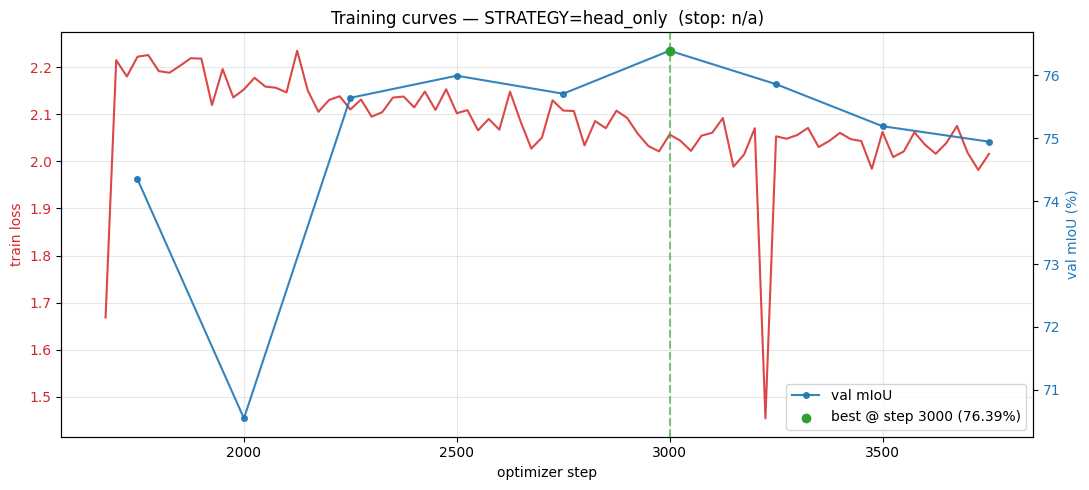

In [ ]:
import matplotlib.pyplot as plt

if not (train_loss_history or val_miou_history):
    print('no history to plot (no completed log/val intervals yet)')
else:
    fig, ax_loss = plt.subplots(figsize=(11, 5))

    if train_loss_history:
        steps_l, losses = zip(*train_loss_history)
        ax_loss.plot(steps_l, losses, color='tab:red', alpha=0.85, label='train loss')
        ax_loss.set_xlabel('optimizer step')
        ax_loss.set_ylabel('train loss', color='tab:red')
        ax_loss.tick_params(axis='y', labelcolor='tab:red')
        ax_loss.grid(True, alpha=0.3)

    if val_miou_history:
        steps_v, mious = zip(*val_miou_history)
        ax_miou = ax_loss.twinx()
        ax_miou.plot(steps_v, [m * 100 for m in mious],
                     color='tab:blue', marker='o', markersize=4, alpha=0.9,
                     label='val mIoU')
        ax_miou.set_ylabel('val mIoU (%)', color='tab:blue')
        ax_miou.tick_params(axis='y', labelcolor='tab:blue')

        # Mark the peak so it's obvious where the model "stopped improving"
        best_step, best_v = max(val_miou_history, key=lambda x: x[1])
        ax_miou.axvline(best_step, color='tab:green', linestyle='--', alpha=0.6)
        ax_miou.scatter([best_step], [best_v * 100], color='tab:green', zorder=5,
                        label=f'best @ step {best_step} ({best_v*100:.2f}%)')
        ax_miou.legend(loc='lower right')

    plt.title(f'Training curves — STRATEGY={STRATEGY}  '
              f'(stop: {stop_reason or "n/a"})')
    fig.tight_layout()

    plot_path = FINAL_DIR / f'training_curves_{STRATEGY}.png'
    fig.savefig(plot_path, dpi=120, bbox_inches='tight')
    print(f'training curves saved to {plot_path}')
    plt.show()